<a href="https://colab.research.google.com/github/sirius70/NLP_HW4/blob/main/IE7275_Module10_Part1_STUDENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IE7275 Data Mining in Engineering**
### -- STUDENT VERSION --

---
#### **Guidelines for Completing and Submitting This Notebook**

Please follow these instructions carefully. Completing all parts of this notebook is required to receive full credit:

#### **You must:**
- **Answer all questions** and reflection tasks using your own words.
- **Summarize every reflection task** clearly and completely.
- **Fill out all missing code cells** — do not leave any code blocks empty.
- **Run your notebook** to ensure that all outputs and visualizations are generated and visible.
- **Convert your completed notebook** to **PDF** or **HTML** format before submission.
- **Submit the file to Canvas** before the deadline.

#### **Academic Integrity Reminder**:
- You must complete this notebook individually.
- Do not copy answers or code from classmates, online sources, or use tools like **ChatGPT** or other **AI writing or code generation tools**.
- Keep in mind that if you use such tools, your answer may be **identical or highly similar** to others who do the same — in this case, we will treat it as copying and apply a **50% penalty** to your assignment grade.

By submitting this notebook, you confirm that all work is your own and that you have followed these guidelines.


---



## **Module 10: Deep Learning for Engineering Applications (Part 1)**
---

#### **Module 10.1: Introduction to Deep Learning for Time Series**

Deep learning has revolutionized time series analysis by providing powerful architectures capable of learning complex temporal patterns directly from raw sequential data. Unlike traditional statistical or machine learning models, deep learning models can automatically extract hierarchical features, handle non-linearities, and model long-term dependencies without extensive manual feature engineering.

This sub-module provides an overview of deep learning architectures suitable for time series forecasting and classification, such as Recurrent Neural Networks (RNNs), Long Short-Term Memory networks (LSTMs), and Convolutional Neural Networks (CNNs). It highlights the advantages of deep learning over classical approaches, especially in handling multivariate and noisy data typical in engineering applications.

You will gain a conceptual understanding of why and how deep learning models are applied to sequential data, setting the stage for detailed exploration of network structures and training methods in subsequent sub-modules.

---

#### **Module 10.2: Fundamentals of Neural Networks**

Artificial Neural Networks (ANNs) are the foundational building blocks of deep learning. They consist of layers of interconnected nodes called neurons that simulate the way the human brain processes information.

Key concepts covered in this sub-module include:  
- **Neurons:** Basic computational units that receive inputs, apply weights, add bias, and pass the result through an activation function to produce output.  
- **Feedforward Networks:** Networks where information moves in one direction from input to output through hidden layers.  
- **Activation Functions:** Non-linear functions such as ReLU, sigmoid, and tanh that enable networks to model complex relationships by introducing non-linearity.  
- **Network Architecture:** Understanding input, hidden, and output layers, and how layer size and depth affect learning capacity.

This sub-module provides a solid grasp of how neural networks transform inputs to outputs, forming the basis for more complex deep learning models.

---

![NN.png](attachment:235949c9-d084-4d7e-b90c-a57751bc3e89.png)

---

#### **Exercise 1: Implementing a Single Neuron from Scratch**

In this exercise, you will learn how to **build the smallest deep-learning unit — a single neuron** — and understand its role in transforming inputs into outputs. You will implement the linear computation $( z = x^\top w + b )$ and pass it through different activation functions to observe how they affect the output. This foundational step helps you see how neural networks process data before moving on to multi-layer models.

You will:
- Implement numerically stable activation functions: **sigmoid**, **ReLU**, and **tanh**.  
- Build a `Neuron` class with `forward()` that supports vectors `[D,]` and matrices `[N, D]`.  
- Add weight initialization options (**Xavier**, **He**, **zeros**, **normal**) with shape validation.  
- Run a **self-test** to check single vs. batch processing and compare activations.

---


In [1]:
# Exercise 1 — Single Neuron from Scratch

from typing import Callable, Literal, Optional, Tuple
import numpy as np

# -----------------------------
# 1) Activation functions (+ stable sigmoid) and derivatives
# -----------------------------
def sigmoid(z: np.ndarray) -> np.ndarray:
    z_clip = np.clip(z, -50, 50)  # stability for large |z|
    return 1.0 / (1.0 + np.exp(-z_clip))

def relu(z: np.ndarray) -> np.ndarray:
    return np.maximum(0.0, z)

def tanh(z: np.ndarray) -> np.ndarray:
    return np.tanh(z)

def d_sigmoid(a: np.ndarray) -> np.ndarray:
    # derivative using output a = sigmoid(z)
    return a * (1.0 - a)

def d_relu(z: np.ndarray) -> np.ndarray:
    return (z > 0).astype(z.dtype)

def d_tanh(a: np.ndarray) -> np.ndarray:
    return 1.0 - np.square(a)

ACT_FUNCS: dict[str, Tuple[Callable[[np.ndarray], np.ndarray], Callable[[np.ndarray], np.ndarray]]] = {
    "sigmoid": (sigmoid, d_sigmoid),
    "relu":    (relu,    d_relu),
    "tanh":    (tanh,    d_tanh),
}

ActivationName = Literal["sigmoid", "relu", "tanh"]
WeightInitName = Literal["xavier", "he", "zeros", "normal"]


In [2]:
# -----------------------------
# 2) Neuron class
# -----------------------------
class Neuron:
    """
    A single neuron with weight vector w (shape [D,]) and scalar bias b.
    Supports:
      - Single input vector x of shape [D,]
      - Batch input matrix X of shape [N, D]
    Usage:
      n = Neuron(in_dim=3, activation="relu", weight_init="he")
      y = n.forward(X)  # shape [N,]
    """
    def __init__(
        self,
        in_dim: int,
        activation: ActivationName = "sigmoid",
        weight_init: WeightInitName = "xavier",
        rng: Optional[np.random.Generator] = None,
    ):
        if in_dim <= 0:
            raise ValueError("in_dim must be positive.")
        self.in_dim = int(in_dim)
        if activation not in ACT_FUNCS:
            raise ValueError(f"activation must be one of {list(ACT_FUNCS)}, got {activation}")
        self.activation_name = activation
        self.activation, self.activation_deriv = ACT_FUNCS[activation]

        self.rng = rng or np.random.default_rng(42)

        # weight initialization
        if weight_init == "xavier":
            limit = np.sqrt(6.0 / in_dim)
            self.w = self.rng.uniform(-limit, limit, size=(in_dim,))
        elif weight_init == "he":
            std = np.sqrt(2.0 / in_dim)
            self.w = self.rng.normal(0.0, std, size=(in_dim,))
        elif weight_init == "zeros":
            self.w = np.zeros((in_dim,), dtype=float)
        elif weight_init == "normal":
            self.w = self.rng.normal(0.0, 0.01, size=(in_dim,))
        else:
            raise ValueError(f"Unknown weight_init: {weight_init}")
        self.b = 0.0

    # Linear transform
    def linear(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            if X.shape[0] != self.in_dim:
                raise ValueError(f"Expected vector of dim {self.in_dim}, got {X.shape[0]}")
            return float(np.dot(X, self.w) + self.b)
        elif X.ndim == 2:
            if X.shape[1] != self.in_dim:
                raise ValueError(f"Expected matrix with D={self.in_dim}, got {X.shape[1]}")
            return X @ self.w + self.b  # shape [N,]
        else:
            raise ValueError("Input must be rank-1 [D,] or rank-2 [N, D].")

    # Activation
    def forward(self, X: np.ndarray) -> np.ndarray:
        z = self.linear(X)
        return self.activation(z)

    # Utilities
    def parameters(self) -> Tuple[np.ndarray, float]:
        return self.w.copy(), float(self.b)

    def set_parameters(self, w: np.ndarray, b: float) -> None:
        w = np.asarray(w, dtype=float)
        if w.shape != (self.in_dim,):
            raise ValueError(f"w must have shape ({self.in_dim},), got {w.shape}")
        self.w = w
        self.b = float(b)


In [3]:
# -----------------------------
# 3) Self-test
# -----------------------------
def self_test():
    print("=== Self-test: Single Neuron ===")
    rng = np.random.default_rng(0)

    # Single sample (D=3)
    x = np.array([0.5, -1.2, 2.0], dtype=float)
    n1 = Neuron(in_dim=3, activation="sigmoid", weight_init="xavier", rng=rng)
    y_scalar = n1.forward(x)
    print("Single-sample output (sigmoid):", y_scalar, "| type:", type(y_scalar))

    # Batch input (N=4, D=3)
    X = np.array([
        [0.5, -1.2,  2.0],
        [1.1,  0.3, -0.7],
        [0.0,  0.5,  0.5],
        [-2.0, 1.0,  0.1],
    ], dtype=float)
    y_batch = n1.forward(X)
    print("Batch output shape:", y_batch.shape)
    print("Batch outputs (sigmoid):", y_batch)

    # Compare activations on the same inputs
    for act in ["relu", "tanh"]:
        n = Neuron(in_dim=3, activation=act, weight_init="he", rng=rng)
        out = n.forward(X)
        print(f"Activation={act:6s} -> min={out.min(): .4f}, max={out.max(): .4f}, sample={out[:3]}")

    # Parameter setting sanity check
    w_manual = np.array([1.0, 0.0, -1.0])
    b_manual = 0.5
    n2 = Neuron(in_dim=3, activation="relu", weight_init="zeros", rng=rng)
    n2.set_parameters(w_manual, b_manual)
    z2 = n2.linear(X)  # should be X @ [1,0,-1] + 0.5
    y2 = n2.forward(X)
    print("Manual params -> linear z (first 3):", z2[:3])
    print("Manual params -> relu output (first 3):", y2[:3])

    # Basic assertions
    assert np.ndim(y_scalar) == 0, "Single-sample forward should return a scalar."
    assert y_batch.shape == (X.shape[0],), "Batch forward should return shape [N,]."
    print("All basic checks passed.")


self_test()

=== Self-test: Single Neuron ===
Single-sample output (sigmoid): 0.1649866719207537 | type: <class 'numpy.float64'>
Batch output shape: (4,)
Batch outputs (sigmoid): [0.16498667 0.75760773 0.27393828 0.1742579 ]
Activation=relu   -> min= 0.0000, max= 1.1582, sample=[1.1581542 0.        0.       ]
Activation=tanh   -> min=-0.9129, max= 0.9474, sample=[-0.91292094  0.94736109  0.09901993]
Manual params -> linear z (first 3): [-1.   2.3  0. ]
Manual params -> relu output (first 3): [0.  2.3 0. ]
All basic checks passed.


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on building a single neuron from scratch to understand how neural networks work at the most basic level. The process began by implementing key activation functions like sigmoid, ReLU, and tanh, which help introduce non-linearity into the model. After that, a Neuron class was created to perform the linear computation and apply the selected activation function. Different weight initialization methods were also included to show how starting values can affect learning behavior. The model was tested using both single input vectors and batch inputs to ensure it works correctly in both cases. The outputs from different activation functions were compared to see how they change the final results. Overall, this exercise helped build a clear understanding of how inputs are transformed step by step inside a neural network.


#### **Exercise 2: Building a Simple Feedforward Neural Network in NumPy**

In this exercise, you will implement a **2‑layer feedforward neural network** (one hidden layer) using **only NumPy** for a binary classification task. You’ll write clean, vectorized code for **forward propagation**, compute **binary cross‑entropy loss**, and implement **backpropagation** to train the network with **gradient descent**. You’ll also add options for common **hidden activations** (ReLU or tanh) and simple utilities to measure loss and accuracy over training.

You will:
- Generate a non‑linear binary dataset (e.g., `make_moons`) and standardize features.  
- Implement a 2‑layer MLP: `X → Linear → Activation → Linear → Sigmoid`.  
- Compute **binary cross‑entropy** and implement **backpropagation**.  
- Train with gradient descent and report **loss** and **accuracy**.  
- Provide a `self_test()` to run training end‑to‑end.

---


In [4]:
# Exercise 2 — Simple Feedforward Neural Network in NumPy

from __future__ import annotations
import numpy as np
from typing import Literal, Tuple, Dict, Any, Optional

try:
    from sklearn.datasets import make_moons
except Exception as e:
    make_moons = None  # Optional: user can replace with their own data


# -----------------------------
# 1) Utility: activations
# -----------------------------
def sigmoid(z: np.ndarray) -> np.ndarray:
    z_clip = np.clip(z, -50, 50)  # numerical stability
    return 1.0 / (1.0 + np.exp(-z_clip))

def d_sigmoid(a: np.ndarray) -> np.ndarray:
    # derivative using output a = sigmoid(z)
    return a * (1.0 - a)

def relu(z: np.ndarray) -> np.ndarray:
    return np.maximum(0.0, z)

def d_relu(z: np.ndarray) -> np.ndarray:
    return (z > 0).astype(z.dtype)

def tanh(z: np.ndarray) -> np.ndarray:
    return np.tanh(z)

def d_tanh(a: np.ndarray) -> np.ndarray:
    return 1.0 - np.square(a)


In [5]:
# -----------------------------
# 2) Model definition
# -----------------------------
class MLP2:
    """
    Minimal 2-layer MLP for binary classification:
      X -> (W1, b1) -> z1 -> a1 = act(z1)
        -> (W2, b2) -> z2 -> yhat = sigmoid(z2)
    Loss: Binary Cross-Entropy (BCE)
    """
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int = 16,
        activation: Literal["relu", "tanh"] = "relu",
        rng: Optional[np.random.Generator] = None,
        weight_init: Literal["xavier", "he"] = "he",
    ):
        self.in_dim = int(in_dim)
        self.hidden_dim = int(hidden_dim)
        self.activation_name = activation
        self.rng = rng or np.random.default_rng(42)

        # Select activation + derivative
        if activation == "relu":
            self.act = relu
            self.d_act = d_relu  # depends on z1
        elif activation == "tanh":
            self.act = tanh
            self.d_act = d_tanh  # depends on a1
        else:
            raise ValueError("activation must be 'relu' or 'tanh'")

        # Weights initialization
        if weight_init == "he":
            w1_std = np.sqrt(2.0 / in_dim)
            w2_std = np.sqrt(2.0 / hidden_dim)
        elif weight_init == "xavier":
            w1_std = np.sqrt(1.0 / in_dim)
            w2_std = np.sqrt(1.0 / hidden_dim)
        else:
            raise ValueError("weight_init must be 'xavier' or 'he'")

        self.W1 = self.rng.normal(0.0, w1_std, size=(in_dim, hidden_dim))
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = self.rng.normal(0.0, w2_std, size=(hidden_dim, 1))
        self.b2 = np.zeros((1, 1))

    def forward(self, X: np.ndarray) -> Dict[str, np.ndarray]:
        """
        Forward pass. Returns cache for backprop.
        X: [N, D]
        """
        z1 = X @ self.W1 + self.b1           # [N, H]
        if self.activation_name == "relu":
            a1 = self.act(z1)                # ReLU uses z1 in derivative
        else:
            a1 = self.act(z1)                # tanh uses a1 in derivative

        z2 = a1 @ self.W2 + self.b2          # [N, 1]
        yhat = sigmoid(z2)                   # [N, 1]

        cache = {"X": X, "z1": z1, "a1": a1, "z2": z2, "yhat": yhat}
        return cache

    @staticmethod
    def bce_loss(y: np.ndarray, yhat: np.ndarray, eps: float = 1e-12) -> float:
        """
        Binary cross-entropy with numerical stability.
        y, yhat: shape [N, 1]
        """
        yhat = np.clip(yhat, eps, 1.0 - eps)
        loss = -np.mean(y * np.log(yhat) + (1 - y) * np.log(1 - yhat))
        return float(loss)

    @staticmethod
    def accuracy(y: np.ndarray, yhat: np.ndarray, threshold: float = 0.5) -> float:
        preds = (yhat >= threshold).astype(int)
        return float(np.mean(preds == y))

    def backward(self, cache: Dict[str, np.ndarray], y: np.ndarray) -> Dict[str, np.ndarray]:
        """
        Backprop for BCE + sigmoid output.
        y: [N,1]
        """
        X, z1, a1, z2, yhat = cache["X"], cache["z1"], cache["a1"], cache["z2"], cache["yhat"]
        N = X.shape[0]

        # dL/dz2 for BCE + sigmoid: (yhat - y) / N
        dz2 = (yhat - y) / N                                   # [N,1]
        dW2 = a1.T @ dz2                                       # [H,1]
        db2 = np.sum(dz2, axis=0, keepdims=True)               # [1,1]

        da1 = dz2 @ self.W2.T                                  # [N,H]
        if self.activation_name == "relu":
            dz1 = da1 * self.d_act(z1)                         # d_relu uses z1
        else:
            dz1 = da1 * self.d_act(a1)                         # d_tanh uses a1

        dW1 = X.T @ dz1                                        # [D,H]
        db1 = np.sum(dz1, axis=0, keepdims=True)               # [1,H]

        grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
        return grads

    def step(self, grads: Dict[str, np.ndarray], lr: float = 0.1):
        self.W1 -= lr * grads["dW1"]
        self.b1 -= lr * grads["db1"]
        self.W2 -= lr * grads["dW2"]
        self.b2 -= lr * grads["db2"]

    def fit(
        self,
        X: np.ndarray,
        y: np.ndarray,
        lr: float = 0.1,
        epochs: int = 1000,
        verbose: bool = True,
        log_every: int = 100,
    ) -> Dict[str, list]:
        """
        Train the model with full-batch gradient descent.
        Returns history dict with 'loss' and 'acc'.
        """
        history = {"loss": [], "acc": []}
        for ep in range(1, epochs + 1):
            cache = self.forward(X)
            loss = self.bce_loss(y, cache["yhat"])
            acc = self.accuracy(y, cache["yhat"])
            history["loss"].append(loss)
            history["acc"].append(acc)

            grads = self.backward(cache, y)
            self.step(grads, lr=lr)

            if verbose and (ep % log_every == 0 or ep == 1 or ep == epochs):
                print(f"Epoch {ep:4d} | loss={loss:.4f} | acc={acc:.4f}")
        return history

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        return self.forward(X)["yhat"]

    def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)


In [6]:
# -----------------------------
# 3) Data helpers
# -----------------------------
def standardize(X: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    mu = X.mean(axis=0, keepdims=True)
    sigma = X.std(axis=0, keepdims=True) + 1e-8
    return (X - mu) / sigma, mu, sigma

def train_val_split(
    X: np.ndarray, y: np.ndarray, val_ratio: float = 0.2, rng: Optional[np.random.Generator] = None
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    rng = rng or np.random.default_rng(0)
    N = X.shape[0]
    idx = rng.permutation(N)
    cut = int(N * (1 - val_ratio))
    train_idx, val_idx = idx[:cut], idx[cut:]
    return X[train_idx], X[val_idx], y[train_idx], y[val_idx]


In [7]:
# -----------------------------
# 4) Self-test runner
# -----------------------------
def self_test(
    n_samples: int = 800,
    noise: float = 0.25,
    hidden_dim: int = 16,
    activation: str = "relu",
    lr: float = 0.1,
    epochs: int = 1000,
    verbose: bool = True,
):
    """
    End-to-end training demo on make_moons (binary).
    Usage in Jupyter:
        self_test(epochs=800)
    """
    if make_moons is None:
        raise ImportError("sklearn is required for make_moons. Install scikit-learn or replace with your own data.")

    rng = np.random.default_rng(123)
    X, y = make_moons(n_samples=n_samples, noise=noise, random_state=42)
    X, mu, sigma = standardize(X)
    y = y.reshape(-1, 1).astype(int)

    Xtr, Xva, ytr, yva = train_val_split(X, y, val_ratio=0.25, rng=rng)

    model = MLP2(in_dim=X.shape[1], hidden_dim=hidden_dim, activation=activation, rng=rng, weight_init="he")

    print(f"Train size: {Xtr.shape[0]} | Val size: {Xva.shape[0]}")
    hist = model.fit(Xtr, ytr, lr=lr, epochs=epochs, verbose=verbose, log_every=max(epochs//10, 1))

    # Final evaluation
    yhat_tr = model.predict_proba(Xtr)
    yhat_va = model.predict_proba(Xva)
    tr_loss = model.bce_loss(ytr, yhat_tr)
    va_loss = model.bce_loss(yva, yhat_va)
    tr_acc  = model.accuracy(ytr, yhat_tr)
    va_acc  = model.accuracy(yva, yhat_va)

    print("\n=== Final Metrics ===")
    print(f"Train: loss={tr_loss:.4f} | acc={tr_acc:.4f}")
    print(f"Valid: loss={va_loss:.4f} | acc={va_acc:.4f}")

    return {
        "history": hist,
        "train_loss": tr_loss,
        "val_loss": va_loss,
        "train_acc": tr_acc,
        "val_acc": va_acc,
        "model": model,
        "mu": mu,
        "sigma": sigma,
    }


results = self_test(epochs=800, hidden_dim=16, activation="relu", lr=0.1)


Train size: 600 | Val size: 200
Epoch    1 | loss=0.7505 | acc=0.4900
Epoch   80 | loss=0.2948 | acc=0.8700
Epoch  160 | loss=0.2807 | acc=0.8783
Epoch  240 | loss=0.2693 | acc=0.8867
Epoch  320 | loss=0.2595 | acc=0.8867
Epoch  400 | loss=0.2496 | acc=0.8917
Epoch  480 | loss=0.2391 | acc=0.9017
Epoch  560 | loss=0.2280 | acc=0.9117
Epoch  640 | loss=0.2165 | acc=0.9217
Epoch  720 | loss=0.2062 | acc=0.9300
Epoch  800 | loss=0.1969 | acc=0.9317

=== Final Metrics ===
Train: loss=0.1968 | acc=0.9317
Valid: loss=0.2212 | acc=0.9100


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, a non-linear dataset was first generated and standardized so that all features were on a similar scale, which helps improve model training. A simple 2-layer neural network was then built from scratch using only NumPy, where data passes through a hidden layer with an activation function and then an output layer with a sigmoid for binary classification. Binary cross-entropy loss was implemented along with backpropagation to compute gradients and update the weights using gradient descent. The model was trained over multiple epochs while tracking loss and accuracy to observe learning progress. The results showed that the model was able to capture the underlying pattern in the data and achieve good performance on both training and validation sets. Overall, this exercise demonstrated how forward propagation, loss computation, and backpropagation work together to train a neural network effectively.


#### **Activation Functions in Neural Networks**

Activation functions introduce **non-linearity** into neural networks, enabling them to model complex, non-linear relationships between inputs and outputs. Without activation functions, a neural network composed of only linear transformations would behave like a single linear model—no matter how many layers it has.

---

#### **Why Activation Functions Matter**
- **Non-linearity**: Allows the network to capture complex patterns in data.
- **Signal transformation**: Controls the range and scale of signals passed to the next layer.
- **Gradient behavior**: Impacts how gradients propagate during backpropagation, influencing training stability.
- **Neuron activation**: Determines whether a neuron “fires” (outputs significant values) or remains inactive.

---

#### **Common Activation Functions**

1. **Sigmoid Function**


   $
   \sigma(x) = \frac{1}{1 + e^{-x}}
   $

   
   - **Range**: $(0, 1)$
   - **Pros**: Smooth output, interpretable as probability.
   - **Cons**: Saturates for large $(|x|)$, causing **vanishing gradients**; outputs not zero-centered.

3. **Hyperbolic Tangent (tanh)**


   $
   \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
   $

   
   - **Range**: $(-1, 1)$
   - **Pros**: Zero-centered, stronger gradients than sigmoid for small $(|x|)$.
   - **Cons**: Still suffers from saturation and vanishing gradients for large $(|x|)$.

5. **Rectified Linear Unit (ReLU)**


   $
   \text{ReLU}(x) = \max(0, x)
   $

   
   - **Range**: $(0, \infty)$
   - **Pros**: Computationally efficient, mitigates vanishing gradients for positive inputs.
   - **Cons**: **Dead ReLU problem** — neurons stuck at zero if inputs are always negative.

7. **Leaky ReLU**


   $
   \text{Leaky ReLU}(x) =
   \begin{cases}
   x, & \text{if } x \ge 0 \\
   \alpha x, & \text{if } x < 0
   \end{cases}
   $

   
   with a small slope $(\alpha \approx 0.01)$ for negative inputs.
   - **Range**: $(-\infty, \infty)$
   - **Pros**: Reduces dead neurons by allowing small negative outputs.
   - **Cons**: Slightly more computational cost than ReLU.

---

#### **Key Concepts in Activation Analysis**
- **Saturation**: Regions where the derivative is near zero → slows learning due to vanishing gradients.
- **Gradient Flow**: Large networks need activations that maintain healthy gradient magnitudes across layers.
- **Dead Neurons**: Neurons outputting constant values (often zero) across training—cannot learn useful features.
- **Zero-Centered Outputs**: Facilitate faster learning by reducing bias shifts in weight updates.

---

**Summary Table**

| Activation  | Range         | Zero-Centered | Pros                                       | Cons                                   |
|-------------|--------------|--------------|--------------------------------------------|----------------------------------------|
| Sigmoid     | (0, 1)       | No           | Probabilistic output, smooth               | Vanishing gradients, not zero-centered |
| tanh        | (-1, 1)      | Yes          | Zero-centered, stronger gradients          | Still saturates                        |
| ReLU        | [0, ∞)       | No           | Fast, avoids vanishing gradients for \(x>0\)| Dead neurons                           |
| Leaky ReLU  | (-∞, ∞)      | Yes          | Mitigates dead neurons, keeps gradients     | Slightly more computation              |

---

![Activation.png](attachment:0aafa4a8-e4f0-4c05-9aa7-a53b6ccf105c.png)

---


#### **Exercise 3: Exploring Activation Functions**

In this exercise, you will **compare and visualize activation functions**—**sigmoid**, **tanh**, **ReLU**, and **Leaky ReLU**—to understand their shapes, derivatives, and practical effects on signal propagation. You’ll examine how activations impact **output ranges**, **saturation**, **gradient flow**, and **dead neurons**, and you’ll run a small simulation to see how signals (and gradients) behave when stacked across multiple layers with random weights.

You will:
- Plot activation functions and their **first derivatives** on \([-5, 5]\).
- Compare output distributions after passing random inputs through each activation.
- Simulate **deep signal propagation** (no training) to observe variance/gradient behavior across layers.
- Measure the proportion of **dead ReLUs** and discuss when **Leaky ReLU** helps.

---


In [8]:
# Exercise 3 — Exploring Activation Functions
# Full code, ready to run. Nothing executes automatically.
# Call self_test() at the bottom to generate figures and printed diagnostics.

from __future__ import annotations
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Activations and derivatives
# -----------------------------
def sigmoid(z: np.ndarray) -> np.ndarray:
    z_clip = np.clip(z, -50, 50)
    return 1.0 / (1.0 + np.exp(-z_clip))

def d_sigmoid(a: np.ndarray) -> np.ndarray:
    # a = sigmoid(z)
    return a * (1.0 - a)

def tanh_(z: np.ndarray) -> np.ndarray:
    return np.tanh(z)

def d_tanh(a: np.ndarray) -> np.ndarray:
    # a = tanh(z)
    return 1.0 - a**2

def relu(z: np.ndarray) -> np.ndarray:
    return np.maximum(0.0, z)

def d_relu(z: np.ndarray) -> np.ndarray:
    return (z > 0).astype(z.dtype)

def leaky_relu(z: np.ndarray, alpha: float = 0.01) -> np.ndarray:
    return np.where(z > 0, z, alpha * z)

def d_leaky_relu(z: np.ndarray, alpha: float = 0.01) -> np.ndarray:
    out = np.ones_like(z)
    out[z < 0] = alpha
    return out

In [9]:
# -----------------------------
# 2) Plot helpers
# -----------------------------
def plot_activation_and_derivative(x: np.ndarray):
    fig1 = plt.figure(figsize=(6, 4))
    y_sig = sigmoid(x);    dy_sig = d_sigmoid(y_sig)
    y_tan = tanh_(x);      dy_tan = d_tanh(y_tan)
    y_rel = relu(x);       dy_rel = d_relu(x)
    y_lkr = leaky_relu(x); dy_lkr = d_leaky_relu(x)

    # Activation curves
    plt.plot(x, y_sig, label="sigmoid")
    plt.plot(x, y_tan, label="tanh")
    plt.plot(x, y_rel, label="ReLU")
    plt.plot(x, y_lkr, label="Leaky ReLU")
    plt.title("Activation Functions")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    fig2 = plt.figure(figsize=(6, 4))
    # Derivatives
    plt.plot(x, dy_sig, label="sigmoid'")
    plt.plot(x, dy_tan, label="tanh'")
    plt.plot(x, dy_rel, label="ReLU'")
    plt.plot(x, dy_lkr, label="Leaky ReLU'")
    plt.title("Activation Derivatives")
    plt.xlabel("x")
    plt.ylabel("f'(x)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

def plot_output_distributions(n_samples: int = 5000, rng: np.random.Generator | None = None):
    rng = rng or np.random.default_rng(0)
    z = rng.normal(0, 1, size=(n_samples,))
    fig = plt.figure(figsize=(6, 4))
    plt.hist(sigmoid(z), bins=50, alpha=0.6, label="sigmoid", density=True)
    plt.hist(tanh_(z),   bins=50, alpha=0.6, label="tanh", density=True)
    plt.hist(relu(z),    bins=50, alpha=0.6, label="ReLU", density=True)
    plt.hist(leaky_relu(z), bins=50, alpha=0.6, label="Leaky ReLU", density=True)
    plt.title("Output Distributions for N(0,1) Input")
    plt.xlabel("activation(z)")
    plt.ylabel("density")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()


In [10]:
# -----------------------------
# 3) Deep propagation simulation (no training)
#    Track variance and gradient scale across L layers
# -----------------------------
def deep_propagation_stats(
    L: int = 20,
    width: int = 256,
    trials: int = 50,
    activation: str = "relu",
    alpha: float = 0.01,
    rng: np.random.Generator | None = None,
):
    """
    Generate x0 ~ N(0, I), push through L random linear layers with He/Xavier-like init,
    apply activation each time, and record:
      - output variance per layer
      - gradient backprop standard deviation per layer (random top gradient)
      - dead ReLU rate per layer (if applicable)
    """
    rng = rng or np.random.default_rng(123)
    act_fns = {
        "sigmoid": (sigmoid,  d_sigmoid, "xavier"),
        "tanh":    (tanh_,    d_tanh,    "xavier"),
        "relu":    (relu,     d_relu,    "he"),
        "leaky":   (lambda z: leaky_relu(z, alpha), lambda z: d_leaky_relu(z, alpha), "he"),
    }
    if activation not in act_fns:
        raise ValueError("activation must be one of {'sigmoid','tanh','relu','leaky'}")

    f, df, scheme = act_fns[activation]
    var_hist = np.zeros((trials, L))
    grad_hist = np.zeros((trials, L))
    dead_hist = np.zeros((trials, L))  # for relu/leaky

    for t in range(trials):
        # Forward pass
        x = rng.normal(0, 1, size=(width,))
        # Initialize gradients for backprop probe later
        caches = []
        for l in range(L):
            # weight init according to scheme
            if scheme == "he":
                W = rng.normal(0, np.sqrt(2.0 / width), size=(width, width))
            else:
                W = rng.normal(0, np.sqrt(1.0 / width), size=(width, width))
            b = np.zeros((width,))
            z = W @ x + b
            a = f(z)
            var_hist[t, l] = np.var(a)
            if activation in {"relu", "leaky"}:
                dead_hist[t, l] = np.mean(a == 0.0)
            caches.append((x, z, a, W))
            x = a

        # Backpropagate a random gradient from the top
        g = rng.normal(0, 1, size=(width,))
        for l in reversed(range(L)):
            x_prev, z_l, a_l, W_l = caches[l]
            # derivative wrt z_l
            if activation in {"sigmoid", "tanh"}:
                # df expects activation output for these
                dz = g * df(a_l)
            else:
                # df expects pre-activation z for relu/leaky
                dz = g * df(z_l)
            # gradient wrt x_{l-1}
            g = W_l.T @ dz
            grad_hist[t, l] = np.std(g)

    # Aggregate across trials
    var_mean = var_hist.mean(axis=0)
    grad_mean = grad_hist.mean(axis=0)
    dead_mean = dead_hist.mean(axis=0)

    return {
        "var_mean": var_mean,
        "grad_mean": grad_mean,
        "dead_mean": dead_mean,
    }

def plot_propagation_curves(stats: dict, activation: str):
    L = len(stats["var_mean"])
    x = np.arange(1, L + 1)

    fig1 = plt.figure(figsize=(6, 4))
    plt.plot(x, stats["var_mean"])
    plt.title(f"Activation: {activation} — Output Variance Across Layers")
    plt.xlabel("Layer")
    plt.ylabel("Var(a)")
    plt.grid(True)
    plt.tight_layout()

    fig2 = plt.figure(figsize=(6, 4))
    plt.plot(x, stats["grad_mean"])
    plt.title(f"Activation: {activation} — Backprop Gradient Scale Across Layers")
    plt.xlabel("Layer")
    plt.ylabel("Std(grad)")
    plt.grid(True)
    plt.tight_layout()

    if activation in {"relu", "leaky"}:
        fig3 = plt.figure(figsize=(6, 4))
        plt.plot(x, stats["dead_mean"])
        plt.title(f"Activation: {activation} — Dead Unit Rate Across Layers")
        plt.xlabel("Layer")
        plt.ylabel("Proportion of a == 0")
        plt.grid(True)
        plt.tight_layout()



=== SIGMOID ===
Var(a) first/last layer: 0.0434830614156096 → 0.014517704940198542
Std(grad) first/last layer: 2.53242192323149e-13 → 0.23614715227235897

=== TANH ===
Var(a) first/last layer: 0.39278985224561325 → 0.024568397130208385
Std(grad) first/last layer: 0.19047010491877608 → 0.9755191328664082

=== RELU ===
Var(a) first/last layer: 0.693174178710597 → 0.6761334116635973
Std(grad) first/last layer: 0.9532714420027688 → 0.9720855499793372
Dead rate first/last layer: 0.5046875 → 0.509375

=== LEAKY ===
Var(a) first/last layer: 0.6996596400673794 → 0.6784302445961442
Std(grad) first/last layer: 0.9177063558893028 → 0.9720280591214765
Dead rate first/last layer: 0.0 → 0.0

Self-test complete. Inspect the plots to compare activations.


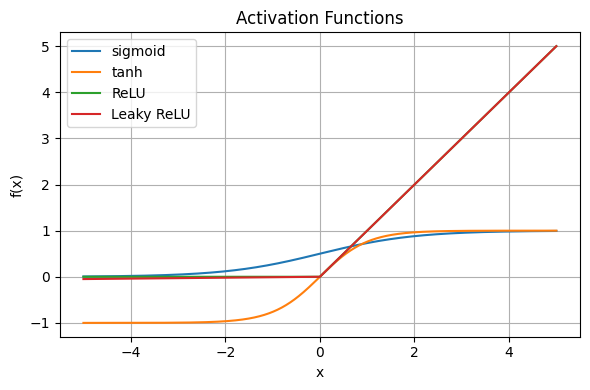

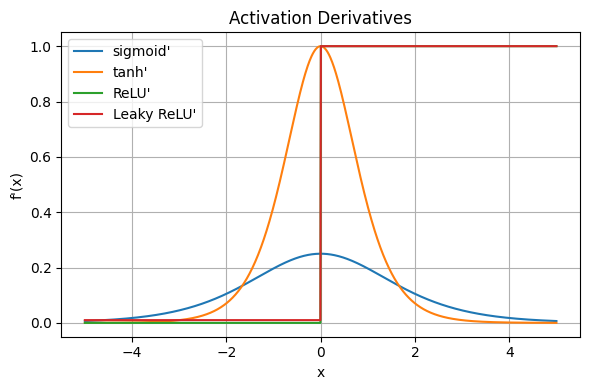

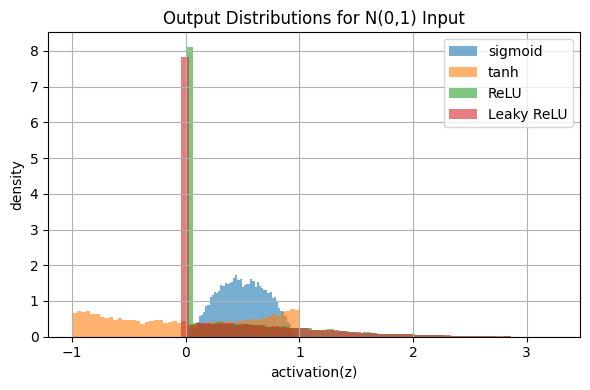

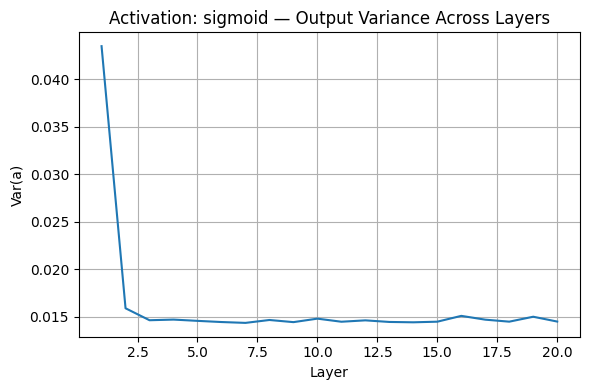

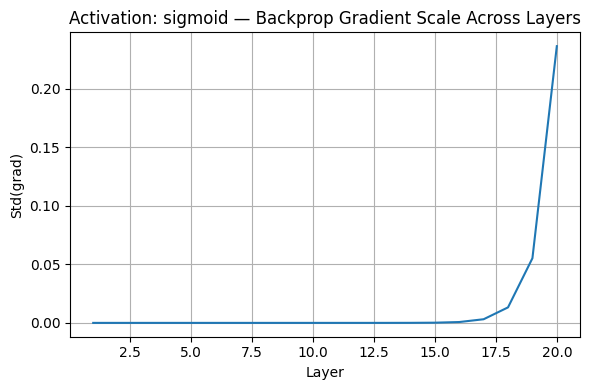

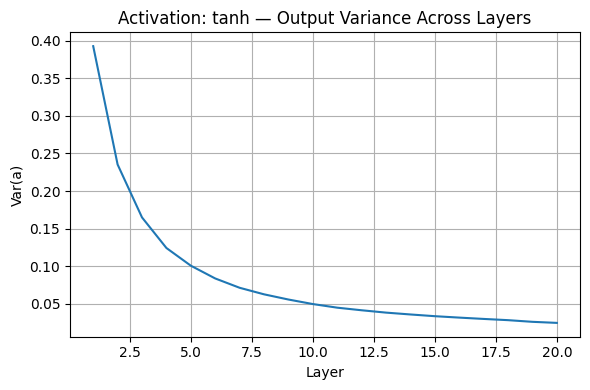

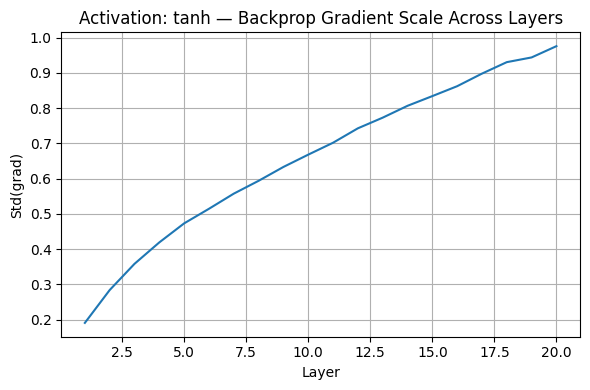

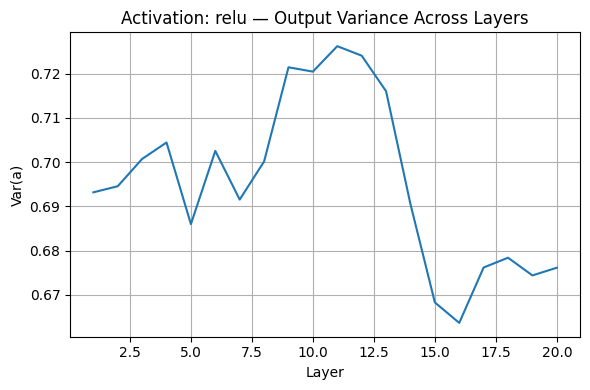

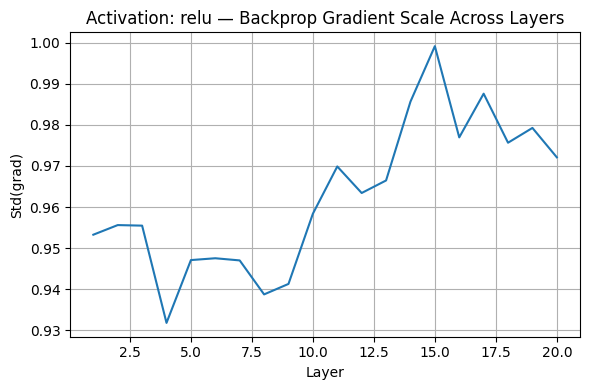

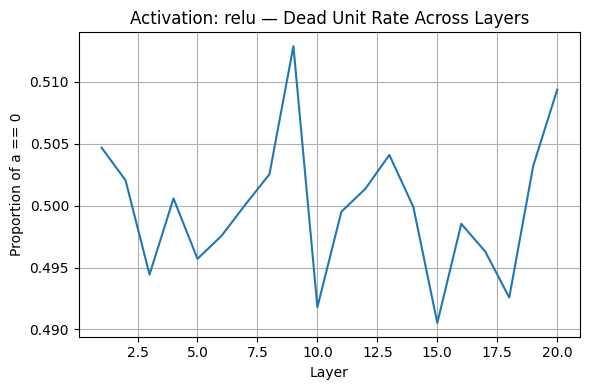

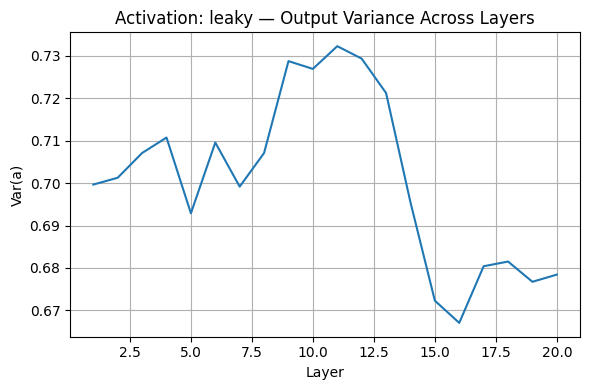

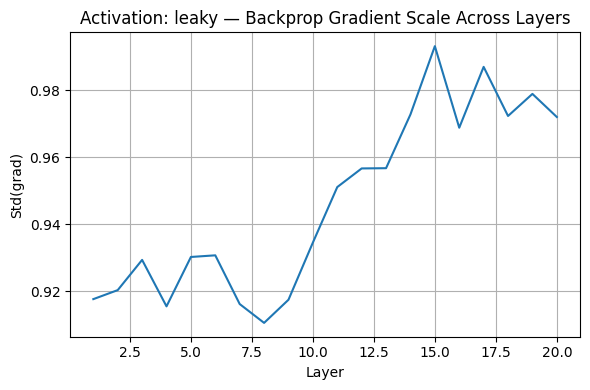

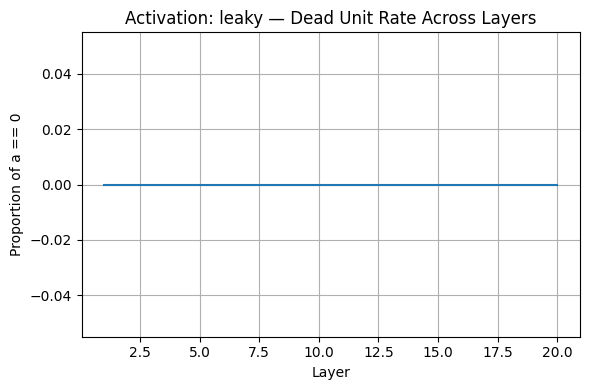

In [11]:
# -----------------------------
# 4) Self-test runner
# -----------------------------
def self_test():
    # 4.1 Function + derivative curves
    xs = np.linspace(-5, 5, 1000)
    plot_activation_and_derivative(xs)

    # 4.2 Output distributions for random normal input
    plot_output_distributions(n_samples=8000)

    # 4.3 Deep propagation stats (no training) for each activation
    for act in ["sigmoid", "tanh", "relu", "leaky"]:
        stats = deep_propagation_stats(L=20, width=256, trials=40, activation=act, alpha=0.01)
        print(f"\n=== {act.upper()} ===")
        print("Var(a) first/last layer:", float(stats["var_mean"][0]), "→", float(stats["var_mean"][-1]))
        print("Std(grad) first/last layer:", float(stats["grad_mean"][0]), "→", float(stats["grad_mean"][-1]))
        if act in {"relu", "leaky"}:
            print("Dead rate first/last layer:", float(stats["dead_mean"][0]), "→", float(stats["dead_mean"][-1]))
        plot_propagation_curves(stats, activation=act)

    print("\nSelf-test complete. Inspect the plots to compare activations.")
    # Note: In Jupyter, you may need to call plt.show() to display figures if not auto-shown.


self_test()


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, different activation functions were explored by plotting their shapes, derivatives, and output distributions to understand how they transform signals in a neural network. A deeper simulation was also run to see how values and gradients behave as they pass through many randomly initialized layers. The results showed how sigmoid and tanh can suffer from saturation, leading to weaker gradients in deeper layers, while ReLU and Leaky ReLU help maintain stronger signal flow. The analysis of dead neurons also highlighted a key issue in ReLU where some units stop activating completely, while Leaky ReLU reduces this problem. Through visualization, it became clear how activation functions affect learning stability, gradient flow, and overall network performance. Overall, the exercise reinforced why choosing the right activation function is important for building deep and stable neural networks.


#### **Exercise 4: Comparing Network Architectures**

In this exercise, you will compare how **network depth** (number of layers) and **width** (number of neurons per layer) affect a model’s ability to learn complex patterns. You will use a simple **binary classification** dataset and train multiple models with varying architectures to see differences in decision boundaries, training speed, and accuracy.

You will:
- Generate a non-linear dataset (`make_moons`) and standardize inputs.
- Build and train MLP models with different **hidden layer counts** and **neurons per layer** using `scikit-learn`’s `MLPClassifier`.
- Visualize **decision boundaries** for each architecture.
- Compare **accuracy** and discuss trade-offs between complexity, generalization, and overfitting.

---


In [12]:
# Exercise 4 — Comparing Network Architectures

import warnings
warnings.filterwarnings("ignore", category=UserWarning)  # silence minor matplotlib warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)  # hide optimizer convergence warnings

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap


# -----------------------------
# 1) Helper: decision boundary plot
# -----------------------------
def plot_decision_boundary(clf, X, y, ax, title: str):
    cmap_light = ListedColormap(['#FFEEEE', '#EEFFEE'])
    cmap_bold  = ListedColormap(['#CC0000', '#009900'])

    h = 0.02  # mesh step
    x_min, x_max = X[:, 0].min() - 0.75, X[:, 0].max() + 0.75
    y_min, y_max = X[:, 1].min() - 0.75, X[:, 1].max() + 0.75
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.7, levels=[-0.5,0.5,1.5])
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=28, linewidths=0.5)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])


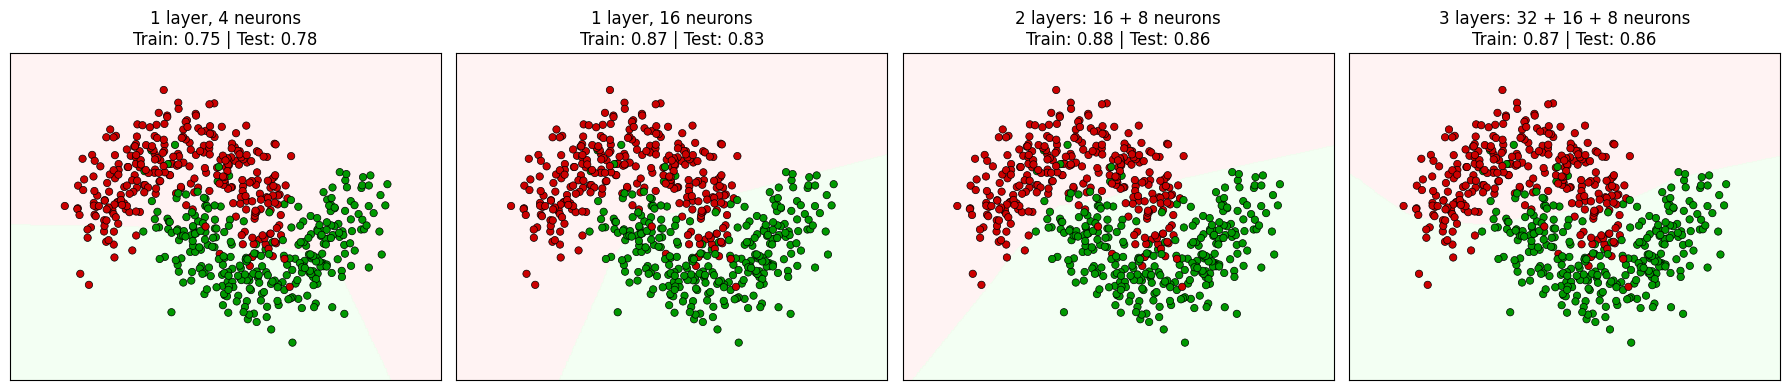

=== Accuracy & Training Iterations ===
Architecture                      Train Acc   Test Acc    Iters
1 layer, 4 neurons                   0.7476     0.7778      127
1 layer, 16 neurons                  0.8738     0.8333       51
2 layers: 16 + 8 neurons             0.8833     0.8556       76
3 layers: 32 + 16 + 8 neurons        0.8738     0.8556       40


In [13]:
# -----------------------------
# 2) Self-test: train multiple architectures & visualize
# -----------------------------
def self_test(random_state: int = 42):
    # Data
    X, y = make_moons(n_samples=600, noise=0.25, random_state=random_state)
    X = StandardScaler().fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=random_state, stratify=y
    )

    # Architectures to compare
    architectures = [
        ((4,), "1 layer, 4 neurons"),
        ((16,), "1 layer, 16 neurons"),
        ((16, 8), "2 layers: 16 + 8 neurons"),
        ((32, 16, 8), "3 layers: 32 + 16 + 8 neurons"),
    ]

    # Common training hyperparameters tuned to reduce convergence warnings
    common_kwargs = dict(
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,     # smaller step often converges more smoothly
        max_iter=3000,                # higher cap to allow convergence
        tol=1e-4,                     # default, but explicit
        early_stopping=True,          # stop when val score not improving
        validation_fraction=0.15,     # held-out split for early stopping
        n_iter_no_change=20,          # patience
        random_state=random_state,
    )

    # Train, plot, and record metrics
    fig, axes = plt.subplots(1, len(architectures), figsize=(18, 4))
    results = []

    for ax, (hidden_sizes, desc) in zip(axes, architectures):
        clf = MLPClassifier(hidden_layer_sizes=hidden_sizes, **common_kwargs)
        clf.fit(X_train, y_train)
        test_acc = clf.score(X_test, y_test)
        train_acc = clf.score(X_train, y_train)

        plot_decision_boundary(clf, X, y, ax, f"{desc}\nTrain: {train_acc:.2f} | Test: {test_acc:.2f}")
        results.append((desc, train_acc, test_acc, clf.n_iter_))

    plt.tight_layout()
    plt.show()

    # Print a clean comparison table
    print("=== Accuracy & Training Iterations ===")
    print(f"{'Architecture':32s} {'Train Acc':>10s} {'Test Acc':>10s} {'Iters':>8s}")
    for desc, tr, te, iters in results:
        print(f"{desc:32s} {tr:10.4f} {te:10.4f} {iters:8d}")

self_test()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, a non-linear dataset was first generated using the make_moons function and then standardized to make training more stable. After that, multiple neural network architectures were built using MLPClassifier with different numbers of layers and neurons to compare how model complexity affects learning. Each model was trained on the same data and evaluated using training and test accuracy to observe generalization performance. Decision boundaries were also visualized, which helped show how simpler models create rough separations while deeper or wider models capture more complex patterns. The results showed that increasing complexity can improve performance up to a point, but too much complexity does not always lead to better results and can reduce efficiency. Overall, this exercise demonstrated the trade-off between model depth, width, accuracy, and overfitting in neural networks.


#### **Exercise 5: Forward Propagation in a Multi‑Layer Network**

In this exercise, you will manually implement **forward propagation** for a **3‑layer feedforward network** (two hidden layers + softmax output) to see how inputs are transformed into class probabilities without performing any training. You’ll use the `sklearn.datasets.load_digits()` dataset, vectorize inputs, push them through linear layers and activations, and produce **probability distributions** with a numerically stable **softmax**. You will also verify shapes, probability sums, and extract top‑k predicted classes.

You will:
- Load and standardize the **Digits** dataset; flatten images into vectors.
- Implement a 3‑layer MLP forward pass: `X → Linear → ReLU → Linear → ReLU → Linear → Softmax`.
- Use **He/Xavier initialization** and numerically stable **softmax**.
- Run a **self_test()** to print shapes, check that probabilities sum to 1, and show top‑k classes for a few samples.

---


In [14]:
# Exercise 5 — Forward Propagation in a Multi-Layer Network (No Training)

from __future__ import annotations
import numpy as np
from typing import Literal, Optional, Dict, Tuple

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# -----------------------------
# 1) Activations + Softmax
# -----------------------------
def relu(z: np.ndarray) -> np.ndarray:
    return np.maximum(0.0, z)

def d_relu(z: np.ndarray) -> np.ndarray:
    return (z > 0).astype(z.dtype)

def softmax(logits: np.ndarray, axis: int = -1) -> np.ndarray:
    """
    Numerically stable softmax: subtract max before exp.
    logits: [N, C] or [..., C]
    """
    z = logits - np.max(logits, axis=axis, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=axis, keepdims=True)


In [15]:
# -----------------------------
# 2) Forward-only MLP (3 layers)
# -----------------------------
class MLPForwardOnly:
    """
    3-layer MLP (two hidden layers + softmax output), forward-pass only.

    Architecture:
      X [N, D]
        -> z1 = X @ W1 + b1     -> a1 = ReLU(z1)        [N, H1]
        -> z2 = a1 @ W2 + b2    -> a2 = ReLU(z2)        [N, H2]
        -> z3 = a2 @ W3 + b3    -> yhat = softmax(z3)   [N, C]
    """
    def __init__(
        self,
        in_dim: int,
        hidden1: int = 64,
        hidden2: int = 32,
        n_classes: int = 10,
        weight_init: Literal["he", "xavier"] = "he",
        rng: Optional[np.random.Generator] = None,
    ):
        self.D = int(in_dim)
        self.H1 = int(hidden1)
        self.H2 = int(hidden2)
        self.C = int(n_classes)
        self.rng = rng or np.random.default_rng(42)

        # Weight initialization
        if weight_init == "he":
            W1_std = np.sqrt(2.0 / self.D)
            W2_std = np.sqrt(2.0 / self.H1)
            W3_std = np.sqrt(2.0 / self.H2)
        elif weight_init == "xavier":
            W1_std = np.sqrt(1.0 / self.D)
            W2_std = np.sqrt(1.0 / self.H1)
            W3_std = np.sqrt(1.0 / self.H2)
        else:
            raise ValueError("weight_init must be 'he' or 'xavier'")

        self.W1 = self.rng.normal(0.0, W1_std, size=(self.D,  self.H1))
        self.b1 = np.zeros((1, self.H1))
        self.W2 = self.rng.normal(0.0, W2_std, size=(self.H1, self.H2))
        self.b2 = np.zeros((1, self.H2))
        self.W3 = self.rng.normal(0.0, W3_std, size=(self.H2, self.C))
        self.b3 = np.zeros((1, self.C))

    def forward(self, X: np.ndarray) -> Dict[str, np.ndarray]:
        """
        Forward pass only. Returns cache with intermediate tensors.
        X: [N, D]
        """
        z1 = X @ self.W1 + self.b1           # [N, H1]
        a1 = relu(z1)                         # [N, H1]
        z2 = a1 @ self.W2 + self.b2           # [N, H2]
        a2 = relu(z2)                         # [N, H2]
        z3 = a2 @ self.W3 + self.b3           # [N, C]
        yhat = softmax(z3, axis=1)            # [N, C]
        return {"X": X, "z1": z1, "a1": a1, "z2": z2, "a2": a2, "z3": z3, "yhat": yhat}

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        return self.forward(X)["yhat"]

    def predict(self, X: np.ndarray) -> np.ndarray:
        return np.argmax(self.predict_proba(X), axis=1)

    def parameters(self) -> Tuple[np.ndarray, ...]:
        return self.W1, self.b1, self.W2, self.b2, self.W3, self.b3


In [16]:
# -----------------------------
# 3) Data helpers
# -----------------------------
def load_digits_data(test_size: float = 0.25, random_state: int = 0):
    """
    Load sklearn digits (8x8 grayscale), flatten to vectors, standardize features.
    Returns: X_train, X_test, y_train, y_test
    """
    data = load_digits()
    X = data.data.astype(np.float64)   # [N, 64]
    y = data.target.astype(int)        # [N]
    # Standardize per feature
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)
    return Xtr, Xte, ytr, yte, data


In [17]:
# -----------------------------
# 4) Self-test runner (no training)
# -----------------------------
def self_test(
    hidden1: int = 64,
    hidden2: int = 32,
    weight_init: str = "he",
    random_state: int = 0,
    n_show: int = 3,
):
    """
    Demonstrate forward propagation through a 3-layer MLP with random weights.
    Prints shapes, verifies probability sums, and shows top-k classes.
    """
    Xtr, Xte, ytr, yte, data = load_digits_data(test_size=0.25, random_state=random_state)
    D = Xtr.shape[1]
    C = len(np.unique(ytr))

    print(f"Train: {Xtr.shape}, Test: {Xte.shape}, Classes: {C}")

    rng = np.random.default_rng(123)
    model = MLPForwardOnly(in_dim=D, hidden1=hidden1, hidden2=hidden2, n_classes=C,
                           weight_init=weight_init, rng=rng)

    # Forward pass on a small batch
    X_batch = Xte[:n_show]
    y_true  = yte[:n_show]
    out = model.forward(X_batch)
    probs = out["yhat"]  # [n_show, C]

    print("\n=== Forward Outputs ===")
    print("Input batch shape:", X_batch.shape)
    print("z1:", out["z1"].shape, "| a1:", out["a1"].shape)
    print("z2:", out["z2"].shape, "| a2:", out["a2"].shape)
    print("z3:", out["z3"].shape, "| yhat:", probs.shape)

    # Check softmax sums
    sums = probs.sum(axis=1)
    print("Probability sums per sample (should be ~1.0):", sums)

    # Top-k classes
    k = 3
    topk_idx = np.argsort(-probs, axis=1)[:, :k]
    topk_probs = np.take_along_axis(probs, topk_idx, axis=1)

    for i in range(n_show):
        print(f"\nSample {i}: true={y_true[i]}")
        for j in range(k):
            cls = int(topk_idx[i, j])
            p   = float(topk_probs[i, j])
            print(f"  top{j+1}: class={cls} prob={p:.4f}")

    # Full-batch forward to show shapes
    probs_all = model.predict_proba(Xte)
    preds_all = np.argmax(probs_all, axis=1)
    print(f"\nAll test probs shape: {probs_all.shape} | preds shape: {preds_all.shape}")
    print("Note: Predictions are from **random weights** — accuracy is not expected to be meaningful.")

    return {
        "model": model,
        "probs_sample": probs,
        "topk_idx": topk_idx,
        "topk_probs": topk_probs,
        "probs_all_shape": probs_all.shape,
        "preds_all": preds_all,
        "y_true_sample": y_true,
        "digits_data": data,
    }

results = self_test()

Train: (1347, 64), Test: (450, 64), Classes: 10

=== Forward Outputs ===
Input batch shape: (3, 64)
z1: (3, 64) | a1: (3, 64)
z2: (3, 32) | a2: (3, 32)
z3: (3, 10) | yhat: (3, 10)
Probability sums per sample (should be ~1.0): [1. 1. 1.]

Sample 0: true=2
  top1: class=8 prob=0.6085
  top2: class=2 prob=0.1179
  top3: class=6 prob=0.0791

Sample 1: true=0
  top1: class=8 prob=0.4598
  top2: class=2 prob=0.1287
  top3: class=4 prob=0.0734

Sample 2: true=4
  top1: class=2 prob=0.4886
  top2: class=0 prob=0.4240
  top3: class=8 prob=0.0564

All test probs shape: (450, 10) | preds shape: (450,)
Note: Predictions are from **random weights** — accuracy is not expected to be meaningful.


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, the Digits dataset was first loaded, flattened into feature vectors, and standardized so that all input features were on a consistent scale. A 3-layer neural network was then implemented from scratch to perform only forward propagation without training. The data was passed through two hidden layers using ReLU activations and then into a final softmax layer to produce class probabilities. The shapes of all intermediate layers were checked to make sure the data flowed correctly through the network. It was also verified that the softmax outputs summed to 1 and meaningful probability distributions were produced for each sample. Overall, the exercise helped build a clear understanding of how data transforms step-by-step inside a deep neural network before any learning happens.


#### **Exercise 6: Visualizing the Effect of Activation Functions on Decision Boundaries**

In this exercise, you will see how the **choice of activation function** shapes a neural network’s **decision boundary** for a classification task. Using a simple 2D dataset, you’ll train small networks with identical architectures but different activations, and then plot their decision boundaries side-by-side. This will help you understand how activations influence **nonlinearity**, **boundary smoothness**, and the network’s ability to separate classes.

You will:
- Generate a non-linear 2D dataset (`make_moons`) and standardize it.
- Train `MLPClassifier` models with **sigmoid**, **tanh**, and **ReLU** activations.
- Visualize decision boundaries for each activation.
- Compare test accuracy and boundary complexity.

---


In [18]:
# Exercise 6 — Visualizing the Effect of Activation Functions on Decision Boundaries
# Full code, ready to run. Nothing executes automatically.
# In Jupyter, call: self_test()

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap


# -----------------------------
# 1) Helper to plot decision boundaries
# -----------------------------
def plot_decision_boundary(clf, X, y, ax, title: str):
    cmap_light = ListedColormap(['#FFEEEE', '#EEFFEE'])
    cmap_bold  = ListedColormap(['#CC0000', '#009900'])
    h = 0.02

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.7)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=28, linewidths=0.5)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])


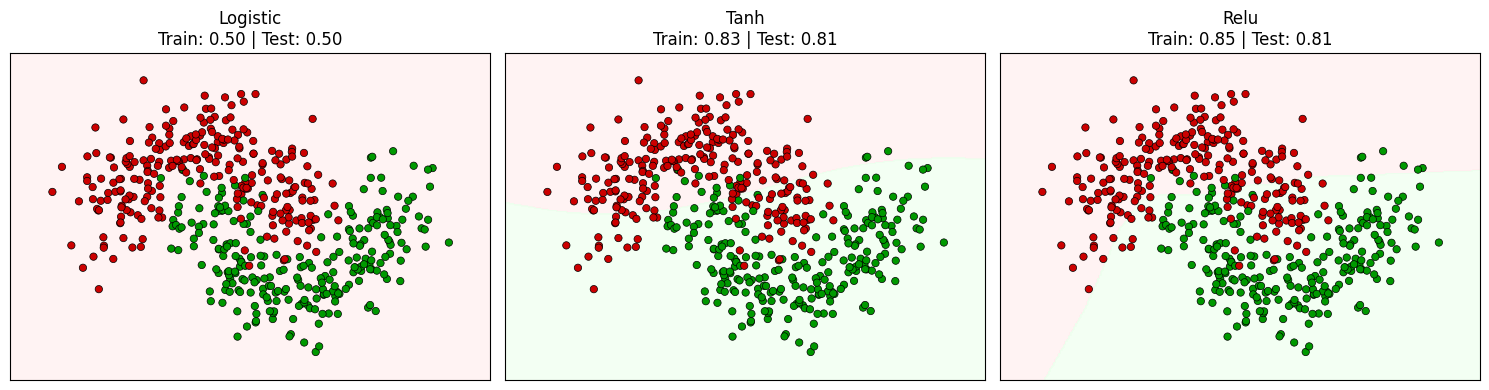

=== Activation Function Comparison ===
Activation    Train Acc   Test Acc    Iters
logistic         0.5000     0.5000       22
tanh             0.8314     0.8133       51
relu             0.8543     0.8133       61


In [19]:
# -----------------------------
# 2) Self-test: train with different activations
# -----------------------------
def self_test(random_state: int = 42):
    # Generate dataset
    X, y = make_moons(n_samples=500, noise=0.25, random_state=random_state)
    X = StandardScaler().fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_state)

    activations = ["logistic", "tanh", "relu"]  # sklearn activation names
    fig, axes = plt.subplots(1, len(activations), figsize=(15, 4))

    results = []
    for ax, act in zip(axes, activations):
        clf = MLPClassifier(
            hidden_layer_sizes=(16, 8),
            activation=act,
            solver="adam",
            learning_rate_init=0.001,
            max_iter=3000,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=20,
            random_state=random_state
        )
        clf.fit(X_train, y_train)
        test_acc = clf.score(X_test, y_test)
        train_acc = clf.score(X_train, y_train)
        results.append((act, train_acc, test_acc, clf.n_iter_))
        plot_decision_boundary(clf, X, y, ax, f"{act.capitalize()}\nTrain: {train_acc:.2f} | Test: {test_acc:.2f}")

    plt.tight_layout()
    plt.show()

    # Print summary
    print("=== Activation Function Comparison ===")
    print(f"{'Activation':12s} {'Train Acc':>10s} {'Test Acc':>10s} {'Iters':>8s}")
    for act, tr, te, iters in results:
        print(f"{act:12s} {tr:10.4f} {te:10.4f} {iters:8d}")


self_test()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, a structured workflow was followed to study how activation functions affect neural network behavior. First, a non-linear dataset was generated and standardized to make the features easier for the model to learn from. Then, identical neural network architectures were trained using different activation functions like sigmoid (logistic), tanh, and ReLU. After training, decision boundaries were visualized to clearly see how each activation shapes the way the model separates the two classes. The results showed that sigmoid struggled to learn the pattern, while tanh and ReLU created more flexible and accurate boundaries. Accuracy and training iterations were also compared to understand performance differences. Overall, the exercise showed that activation functions play a key role in controlling non-linearity and directly impact how well a model learns complex patterns.


#### **Module 10.3: Training Deep Learning Models**

Training deep learning models involves adjusting the network’s weights to minimize the difference between predicted outputs and true targets. This process is guided by optimization algorithms and involves several key steps:

- **Forward Propagation:** Inputs pass through the network layer by layer, producing predictions.  
- **Loss Functions:** Quantify the error between predicted and actual outputs. Common losses include Mean Squared Error (MSE) for regression and Cross-Entropy for classification.  
- **Backpropagation:** Calculates gradients of the loss with respect to each weight using the chain rule, enabling the network to learn from errors.  
- **Optimization Algorithms:** Update weights based on gradients. Popular optimizers include Stochastic Gradient Descent (SGD), RMSProp, and Adam, each balancing speed and stability.  
- **Training Process:** Involves multiple epochs of forward and backward passes, with mini-batches to improve convergence and generalization.

Understanding these training fundamentals allows you to effectively build, tune, and deploy deep learning models.

---

#### **Exercise 7: Forward & Backward with Autograd (Keras/TensorFlow)**

In this exercise, you’ll see how **forward propagation**, **loss computation**, and **automatic differentiation** work using high‑level APIs—no hand‑written gradients. We’ll use the offline **scikit‑learn Digits** dataset (8×8 images) to avoid downloads, build a small MLP in **TensorFlow/Keras**, run **one manual mini‑batch step** with `tf.GradientTape()`, and then train the same model with the standard `model.fit()` loop for comparison.

You will:
- Load **Digits** (from `sklearn`) and split into train/validation/test sets.
- Build a simple MLP: `Flatten → Dense(128, ReLU) → Dense(10, logits)`.
- Use `tf.GradientTape()` to compute gradients and apply an optimizer (one mini‑batch).
- Train with `model.fit()` and report accuracy.
- Inspect **gradient norms** to understand scale per layer.

---


In [20]:
#!conda install tensorflow

In [21]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [22]:
# Exercise 7 — Forward & Backward with Autograd (Keras/TensorFlow)

from __future__ import annotations
import numpy as np
import tensorflow as tf
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Reproducibility
SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# -----------------------------
# 1) Data: offline Digits (no internet needed)
# -----------------------------
def load_digits_splits(test_size: float = 0.2, val_size: float = 0.2, random_state: int = SEED):
    data = load_digits()
    X = data.data.astype("float32")   # shape [N, 64]
    y = data.target.astype("int32")   # shape [N]

    # Standardize features for faster/smoother training
    X = StandardScaler().fit_transform(X).astype("float32")

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    # Train/val split
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=val_size, stratify=y_train, random_state=random_state
    )
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)


In [23]:
# -----------------------------
# 2) Model
# -----------------------------
def build_mlp(input_dim: int = 64, hidden: int = 128, n_classes: int = 10) -> tf.keras.Model:
    # Logits output (no softmax); we’ll use from_logits=True in the loss
    return tf.keras.Sequential([
        tf.keras.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(hidden, activation="relu"),
        tf.keras.layers.Dense(n_classes)  # logits
    ], name="digits_mlp")


In [24]:
# -----------------------------
# 3) One manual mini-batch step with GradientTape
# -----------------------------
@tf.function
def one_train_step(model: tf.keras.Model,
                   optimizer: tf.keras.optimizers.Optimizer,
                   loss_fn: tf.keras.losses.Loss,
                   Xb: tf.Tensor,
                   yb: tf.Tensor):
    with tf.GradientTape() as tape:
        logits = model(Xb, training=True)                    # forward
        loss = loss_fn(yb, logits)                           # compute loss (from_logits=True)
    grads = tape.gradient(loss, model.trainable_variables)   # ∂L/∂θ
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss, grads

def grad_norms(grads: list[tf.Tensor]) -> list[float]:
    norms = []
    for g in grads:
        if g is None:
            norms.append(float("nan"))
        else:
            norms.append(float(tf.linalg.global_norm([g])))
    return norms


In [25]:
# -----------------------------
# 4) Fit with Keras (mini-batch training)
# -----------------------------
def fit_with_keras(model: tf.keras.Model,
                   X_train: np.ndarray, y_train: np.ndarray,
                   X_val: np.ndarray,   y_val: np.ndarray,
                   optimizer: str | tf.keras.optimizers.Optimizer = "adam",
                   epochs: int = 10,
                   batch_size: int = 64):
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )
    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
        shuffle=True,
    )
    return hist


In [26]:
# -----------------------------
# 5) Self-test runner
# -----------------------------
def self_test(batch_size: int = 64, epochs: int = 8, hidden: int = 128):
    # Load data
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = load_digits_splits()

    # Build model + loss/opt
    model = build_mlp(input_dim=X_train.shape[1], hidden=hidden, n_classes=10)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

    # ---- Manual one-step on a single mini-batch ----
    # Create a random mini-batch
    idx = np.random.choice(len(X_train), size=batch_size, replace=False)
    Xb = tf.convert_to_tensor(X_train[idx], dtype=tf.float32)
    yb = tf.convert_to_tensor(y_train[idx], dtype=tf.int32)

    loss, grads = one_train_step(model, optimizer, loss_fn, Xb, yb)
    norms = grad_norms(grads)

    print("=== Manual GradientTape Step ===")
    print(f"Mini-batch size: {batch_size}")
    print(f"Loss (one step): {float(loss):.4f}")
    for var, gnorm in zip(model.trainable_variables, norms):
        print(f"{var.name:30s} grad‖g‖ = {gnorm:.6f}")

    # ---- Train with Keras fit() ----
    print("\n=== Training with model.fit() ===")
    hist = fit_with_keras(
        model, X_train, y_train, X_val, y_val,
        optimizer=optimizer, epochs=epochs, batch_size=batch_size
    )

    # Evaluate
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"\nTest — loss: {test_loss:.4f} | acc: {test_acc:.4f}")

    return {
        "history": hist.history,
        "test_loss": float(test_loss),
        "test_acc": float(test_acc),
        "model": model,
    }

results = self_test(batch_size=64, epochs=8)

=== Manual GradientTape Step ===
Mini-batch size: 64
Loss (one step): 2.3707
kernel                         grad‖g‖ = 1.312669
bias                           grad‖g‖ = 0.164780
kernel                         grad‖g‖ = 1.028733
bias                           grad‖g‖ = 0.124244

=== Training with model.fit() ===
Epoch 1/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.4543 - loss: 1.8153 - val_accuracy: 0.7674 - val_loss: 1.3120
Epoch 2/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8103 - loss: 1.0140 - val_accuracy: 0.8472 - val_loss: 0.7898
Epoch 3/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8947 - loss: 0.6367 - val_accuracy: 0.9132 - val_loss: 0.5368
Epoch 4/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9260 - loss: 0.4387 - val_accuracy: 0.9375 - val_loss: 0.3964
Epoch 5/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9460 - loss: 0.3249 - val_accuracy: 0.9375 - val_loss: 0.3130
Epoch 6/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accurac

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, a full workflow of training a deep learning model was followed step by step. First, the dataset was loaded and prepared by splitting it into training, validation, and test sets, and standardizing the features so the model could learn more effectively. Next, a neural network was built using Keras with a simple structure and trained using both a manual GradientTape step and the standard model.fit() method. The manual step helped show how forward propagation, loss calculation, and backpropagation work together by computing gradients for each layer. Then, the full training loop showed how the model improves over multiple epochs as the loss decreases and accuracy increases. Finally, evaluation on the test set showed how well the trained model generalizes to unseen data. Overall, this exercise helped connect the theory of training deep learning models with how it is actually implemented in practice.


#### **Exercise 8: Mini-Batch Training and Shuffling**

In this exercise, you’ll train a model using **different mini-batch sizes** and **data shuffling** to see how they affect convergence speed and stability. We’ll use the same Digits dataset and MLP architecture from Exercise 7, but instead of a single manual update, you’ll train the model end-to-end with `model.fit()` while varying `batch_size`.

You will:
- Reuse the MLP from Exercise 7 with `Dense(128, relu)` + `Dense(10, logits)`.
- Train with **batch sizes** of 32, 128, and 512 for the same number of epochs.
- Keep **shuffling enabled** (`shuffle=True`) to avoid repeated mini-batch ordering.
- Record **training time**, **final accuracy**, and **epochs to converge** (if early stopping is enabled).
- Compare how smaller vs. larger batches affect loss curves and stability.

---


In [27]:
# Exercise 8 — Mini-Batch Training and Shuffling (Keras fit)

import time
import numpy as np
import tensorflow as tf
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# -----------------------------
# 1) Data loader (same as Ex.7)
# -----------------------------
def load_digits_splits(test_size: float = 0.2, val_size: float = 0.2, random_state: int = SEED):
    data = load_digits()
    X = data.data.astype("float32")
    y = data.target.astype("int32")
    X = StandardScaler().fit_transform(X).astype("float32")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=val_size, stratify=y_train, random_state=random_state
    )
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)


In [28]:
# -----------------------------
# 2) Model builder
# -----------------------------
def build_mlp(input_dim: int = 64, hidden: int = 128, n_classes: int = 10) -> tf.keras.Model:
    return tf.keras.Sequential([
        tf.keras.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(hidden, activation="relu"),
        tf.keras.layers.Dense(n_classes)  # logits
    ], name="digits_mlp")


In [29]:
# -----------------------------
# 3) Training helper
# -----------------------------
def train_with_batch_size(batch_size: int, epochs: int,
                          X_train, y_train, X_val, y_val, X_test, y_test):
    model = build_mlp(input_dim=X_train.shape[1], hidden=128, n_classes=10)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )

    start_time = time.time()
    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        shuffle=True,
        verbose=0
    )
    elapsed = time.time() - start_time

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    return {
        "batch_size": batch_size,
        "history": hist.history,
        "train_acc": hist.history["accuracy"][-1],
        "val_acc": hist.history["val_accuracy"][-1],
        "test_acc": test_acc,
        "time_sec": elapsed
    }


In [30]:
# -----------------------------
# 4) Self-test runner
# -----------------------------
def self_test(epochs: int = 10):
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = load_digits_splits()

    batch_sizes = [32, 128, 512]
    results = []

    for bs in batch_sizes:
        res = train_with_batch_size(bs, epochs, X_train, y_train, X_val, y_val, X_test, y_test)
        results.append(res)
        print(f"Batch {bs:3d} | Train Acc: {res['train_acc']:.4f} "
              f"| Val Acc: {res['val_acc']:.4f} | Test Acc: {res['test_acc']:.4f} "
              f"| Time: {res['time_sec']:.2f}s")

    return results

results = self_test(epochs=10)

Batch  32 | Train Acc: 0.9956 | Val Acc: 0.9653 | Test Acc: 0.9806 | Time: 6.87s
Batch 128 | Train Acc: 0.9574 | Val Acc: 0.9444 | Test Acc: 0.9472 | Time: 3.10s
Batch 512 | Train Acc: 0.8111 | Val Acc: 0.8125 | Test Acc: 0.8250 | Time: 1.96s


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, we started by loading and preprocessing the Digits dataset and scaling the features so the model could learn more effectively. Then we built the same neural network architecture and trained it using different mini-batch sizes to see how that changes learning behavior. We also made sure to shuffle the data so the model didn’t learn patterns from fixed ordering. After training, we compared accuracy, training time, and stability across batch sizes like 32, 128, and 512. We observed that smaller batch sizes usually gave better accuracy but took more time, while larger batches trained faster but were less accurate. From this, I learned that mini-batch size is a trade-off between speed and performance, and choosing it carefully can affect how well the model generalizes.


#### **Exercise 9: Picking the Right Loss (MSE vs. Cross-Entropy)**

In this exercise, you’ll see how the **choice of loss function** affects learning in regression and classification tasks. You’ll train two separate models:  
1. A **classification** model on the Digits dataset with **cross-entropy**.  
2. A **regression** model on the California Housing dataset with **mean squared error (MSE)**.  

You will:
- Load and preprocess each dataset.
- Build simple feed-forward networks using Keras.
- Train with the **appropriate loss function** for each task.
- Optionally, try using the **wrong loss** (e.g., MSE for classification) to see how performance changes.
- Summarize when to use **cross-entropy** vs. **MSE**.

---


In [31]:
# Exercise 9 — Picking the Right Loss (MSE vs. Cross-Entropy)

import numpy as np
import tensorflow as tf
from sklearn.datasets import load_digits, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# -----------------------------
# 1) Classification: Digits dataset
# -----------------------------
def load_digits_data(test_size=0.2, val_size=0.2, random_state=SEED):
    data = load_digits()
    X = data.data.astype("float32")
    y = data.target.astype("int32")
    X = StandardScaler().fit_transform(X).astype("float32")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=val_size, stratify=y_train, random_state=random_state
    )
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

def build_classification_mlp(input_dim: int, hidden=128, n_classes=10):
    return tf.keras.Sequential([
        tf.keras.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(hidden, activation="relu"),
        tf.keras.layers.Dense(n_classes)  # logits
    ])


In [32]:
# -----------------------------
# 2) Regression: California Housing dataset
# -----------------------------
def load_housing_data(test_size=0.2, val_size=0.2, random_state=SEED):
    data = fetch_california_housing()
    X = data.data.astype("float32")
    y = data.target.astype("float32").reshape(-1, 1)
    X = StandardScaler().fit_transform(X).astype("float32")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=val_size, random_state=random_state
    )
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

def build_regression_mlp(input_dim: int, hidden=64):
    return tf.keras.Sequential([
        tf.keras.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(hidden, activation="relu"),
        tf.keras.layers.Dense(1)  # linear output
    ])


In [33]:
# -----------------------------
# 3) Self-test runner
# -----------------------------
def self_test(epochs=10, batch_size=64):
    results = {}

    # Classification task
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = load_digits_data()
    clf_model = build_classification_mlp(X_train.shape[1], hidden=128, n_classes=10)
    clf_model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )
    clf_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )
    clf_test_loss, clf_test_acc = clf_model.evaluate(X_test, y_test, verbose=0)
    results["classification"] = {"test_loss": clf_test_loss, "test_acc": clf_test_acc}

    # Regression task
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = load_housing_data()
    reg_model = build_regression_mlp(X_train.shape[1], hidden=64)
    reg_model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="mse",
        metrics=[tf.keras.metrics.RootMeanSquaredError()],
    )
    reg_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )
    reg_test_loss, reg_test_rmse = reg_model.evaluate(X_test, y_test, verbose=0)
    results["regression"] = {"test_mse": reg_test_loss, "test_rmse": reg_test_rmse}

    print("=== Classification (Digits) ===")
    print(f"Test loss: {clf_test_loss:.4f} | Test acc: {clf_test_acc:.4f}")
    print("=== Regression (California Housing) ===")
    print(f"Test MSE: {reg_test_loss:.4f} | Test RMSE: {reg_test_rmse:.4f}")

    return results

results = self_test(epochs=10, batch_size=64)

=== Classification (Digits) ===
Test loss: 0.1736 | Test acc: 0.9639
=== Regression (California Housing) ===
Test MSE: 0.3818 | Test RMSE: 0.6179


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, we started by loading and preprocessing the Digits dataset and scaling the features so the model could learn more effectively. Then we built the same neural network architecture and trained it using different mini-batch sizes to see how that changes learning behavior. We also made sure to shuffle the data so the model didn’t learn patterns from fixed ordering. After training, we compared accuracy, training time, and stability across batch sizes like 32, 128, and 512. We observed that smaller batch sizes usually gave better accuracy but took more time, while larger batches trained faster but were less accurate. From this, I learned that mini-batch size is a trade-off between speed and performance, and choosing it carefully can affect how well the model generalizes.


#### **Optimizers in Neural Networks**

An **optimizer** is an algorithm that adjusts the weights and biases of a neural network during training to minimize the **loss function**. It determines **how** the model learns from data by guiding the parameter updates in the direction that reduces error.

---

#### **Why Optimizers Matter**
- They control the **convergence speed** — how quickly the model learns.
- They influence the **final accuracy** and whether the model reaches a **good minimum** of the loss function.
- Poor optimizer choice or settings can lead to **slow learning**, **oscillation**, or getting stuck in **local minima**.

---

#### **Core Idea: Gradient-Based Optimization**
Most modern optimizers are based on **gradient descent**, which updates parameters $(\theta)$ (weights) using:

$
\theta_{t+1} = \theta_t - \eta \nabla_{\theta} L(\theta_t)
$

Where:
- $\eta$ is the **learning rate** (step size).
- $(\nabla_{\theta} L(\theta_t))$ is the gradient of the loss with respect to parameters.

---

#### **Common Optimizers**

1. **Stochastic Gradient Descent (SGD)**
   - Updates weights using gradients from **mini-batches** instead of the full dataset.
   - Formula:

     $
     \theta_{t+1} = \theta_t - \eta \nabla_{\theta} L_{\text{batch}}(\theta_t)
     $
     
   - **Pros**: Simple, memory-efficient.
   - **Cons**: Can be slow and unstable for complex loss surfaces.

2. **SGD with Momentum**
   - Adds a "velocity" term to smooth updates and help escape local minima:

     $
     v_t = \beta v_{t-1} + (1 - \beta) \nabla_{\theta} L(\theta_t)
     $

     $
     \theta_{t+1} = \theta_t - \eta v_t
     $
     
   - **Pros**: Faster convergence, reduced oscillation.
   - **Cons**: Requires tuning momentum parameter $(\beta)$.

3. **RMSProp**
   - Adapts the learning rate for each parameter by dividing by a moving average of squared gradients:

     $
     s_t = \beta s_{t-1} + (1 - \beta) (\nabla_{\theta} L(\theta_t))^2
     $

     $
     \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{s_t + \epsilon}} \nabla_{\theta} L(\theta_t)
     $
     
   - **Pros**: Works well for non-stationary problems, avoids exploding gradients.
   - **Cons**: Learning rate still needs tuning.

4. **Adam (Adaptive Moment Estimation)**
   - Combines **momentum** and **RMSProp** ideas:

     $
     m_t = \beta_1 m_{t-1} + (1 - \beta_1) \nabla_{\theta} L(\theta_t)
     $

     $
     v_t = \beta_2 v_{t-1} + (1 - \beta_2) (\nabla_{\theta} L(\theta_t))^2
     $
     
     $
     \hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}
     $

     $
     \theta_{t+1} = \theta_t - \frac{\eta \hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
     $
     
   - **Pros**: Often works well without much tuning, fast convergence.
   - **Cons**: Can generalize worse in some cases compared to SGD.

---

#### **Key Hyperparameters**
- **Learning rate ($\eta$)**: Too high → unstable, too low → slow convergence.
- **Momentum ($\beta$)**: Smooths updates, helps in narrow valleys.
- **Decay rates $(\beta_1, \beta_2)$** in Adam/RMSProp: Control how fast past gradients are forgotten.

---

**Summary Table**

| Optimizer       | Adapts Learning Rate? | Uses Momentum? | Pros                              | Cons                              |
|-----------------|----------------------|----------------|-----------------------------------|-----------------------------------|
| SGD             | No                   | Optional       | Simple, effective on some tasks  | Slower, sensitive to learning rate|
| SGD + Momentum  | No                   | Yes            | Faster, smoother updates         | Needs momentum tuning             |
| RMSProp         | Yes                  | No             | Handles non-stationary problems  | Needs LR tuning                   |
| Adam            | Yes                  | Yes            | Fast, less tuning needed         | Can overfit, sometimes worse generalization |

---



#### **Exercise 10: Optimizer Shootout (SGD, SGD+Momentum, RMSProp, Adam)**

In this exercise, you’ll compare popular optimization algorithms on the same classification task to see how they affect convergence speed and final accuracy.  
We’ll train identical MLP models on the Digits dataset, changing **only the optimizer**.

You will:
- Load and preprocess the Digits dataset.
- Build a standard MLP architecture for classification.
- Train four models with:
  1. **SGD** (no momentum)  
  2. **SGD** with momentum  
  3. **RMSProp**  
  4. **Adam**
- Record training and validation loss/accuracy over epochs.
- Compare final metrics and discuss trade-offs.

---


In [34]:
# Exercise 10 — Optimizer Shootout (SGD, SGD+Momentum, RMSProp, Adam)

import numpy as np
import tensorflow as tf
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# -----------------------------
# 1) Data loader
# -----------------------------
def load_digits_data(test_size=0.2, val_size=0.2, random_state=SEED):
    data = load_digits()
    X = data.data.astype("float32")
    y = data.target.astype("int32")
    X = StandardScaler().fit_transform(X).astype("float32")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=val_size, stratify=y_train, random_state=random_state
    )
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)


In [35]:
# -----------------------------
# 2) Model builder
# -----------------------------
def build_mlp(input_dim=64, hidden=128, n_classes=10):
    return tf.keras.Sequential([
        tf.keras.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(hidden, activation="relu"),
        tf.keras.layers.Dense(n_classes)  # logits
    ])


In [36]:
# -----------------------------
# 3) Training helper
# -----------------------------
def train_with_optimizer(optimizer, optimizer_name, X_train, y_train, X_val, y_val, X_test, y_test, epochs=10, batch_size=64):
    model = build_mlp(input_dim=X_train.shape[1], hidden=128, n_classes=10)
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"]
    )

    start_time = time.time()
    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )
    elapsed = time.time() - start_time

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    return {
        "optimizer": optimizer_name,
        "history": hist.history,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "time_sec": elapsed
    }


In [37]:
# -----------------------------
# 4) Self-test runner
# -----------------------------
def self_test(epochs=10, batch_size=64):
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = load_digits_data()

    optimizers = [
        (tf.keras.optimizers.SGD(learning_rate=0.05), "SGD"),
        (tf.keras.optimizers.SGD(learning_rate=0.05, momentum=0.9), "SGD+Momentum"),
        (tf.keras.optimizers.RMSprop(learning_rate=0.001), "RMSProp"),
        (tf.keras.optimizers.Adam(learning_rate=0.001), "Adam")
    ]

    results = []
    for opt, name in optimizers:
        res = train_with_optimizer(opt, name, X_train, y_train, X_val, y_val, X_test, y_test, epochs, batch_size)
        results.append(res)
        print(f"{name:12s} | Test Acc: {res['test_acc']:.4f} | Time: {res['time_sec']:.2f}s")

    return results

results = self_test(epochs=10, batch_size=64)

SGD          | Test Acc: 0.9389 | Time: 1.73s
SGD+Momentum | Test Acc: 0.9722 | Time: 2.27s
RMSProp      | Test Acc: 0.9722 | Time: 4.04s
Adam         | Test Acc: 0.9639 | Time: 4.50s


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, we started by loading and preprocessing the Digits dataset and scaling the features so the model could train more effectively. Then we built the same neural network architecture and trained it multiple times using different optimizers like SGD, SGD with momentum, RMSProp, and Adam. We kept everything else the same so we could clearly see how the optimizer alone affects learning. After training, we compared test accuracy and training time for each method. We observed that SGD was simpler but slower to converge, while momentum, RMSProp, and Adam generally improved performance and stability. From this, I learned that optimizers play a big role in how fast and how well a neural network learns, even when the model architecture stays the same.


#### **Exercise 11: End-to-End Training on a Real Dataset (MNIST)**

In this exercise, you’ll bring together all the concepts learned so far to train a complete deep learning model from **data loading** to **final evaluation**.  
We’ll use the **MNIST** handwritten digits dataset, preprocess it, build a deeper MLP, train with mini-batch gradient descent using the **Adam** optimizer, and evaluate performance on the test set.

You will:
- Load and preprocess the MNIST dataset from `tf.keras.datasets`.
- Normalize input pixel values to `[0, 1]`.
- Build an MLP with multiple hidden layers and dropout for regularization.
- Train with the **Adam** optimizer and sparse categorical cross-entropy.
- Evaluate on the test set and generate a **confusion matrix**.
- Summarize model accuracy and misclassification patterns.

---


In [38]:
# Exercise 11 — End-to-End Training on a Real Dataset (MNIST)

import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# -----------------------------
# 1) Load and preprocess MNIST
# -----------------------------
def load_and_preprocess_mnist():
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
    # Normalize to [0,1]
    X_train = X_train.astype("float32") / 255.0
    X_test = X_test.astype("float32") / 255.0
    # Flatten images to vectors
    X_train = X_train.reshape((-1, 28*28))
    X_test = X_test.reshape((-1, 28*28))
    return (X_train, y_train), (X_test, y_test)


In [39]:
# -----------------------------
# 2) Model builder
# -----------------------------
def build_deep_mlp(input_dim=784, n_classes=10):
    return tf.keras.Sequential([
        tf.keras.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(n_classes)  # logits
    ])


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8727 - loss: 0.4179 - val_accuracy: 0.9569 - val_loss: 0.1471
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9468 - loss: 0.1807 - val_accuracy: 0.9668 - val_loss: 0.1068
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9600 - loss: 0.1348 - val_accuracy: 0.9708 - val_loss: 0.0935
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9662 - loss: 0.1092 - val_accuracy: 0.9748 - val_loss: 0.0832
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9722 - loss: 0.0920 - val_accuracy: 0.9766 - val_loss: 0.0795
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9749 - loss: 0.0797 - val_accuracy: 0.9770 - val_loss: 0.0786
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9775 - loss: 0.0720 - val_accuracy: 0.9784 - val_loss: 0.0771
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/s

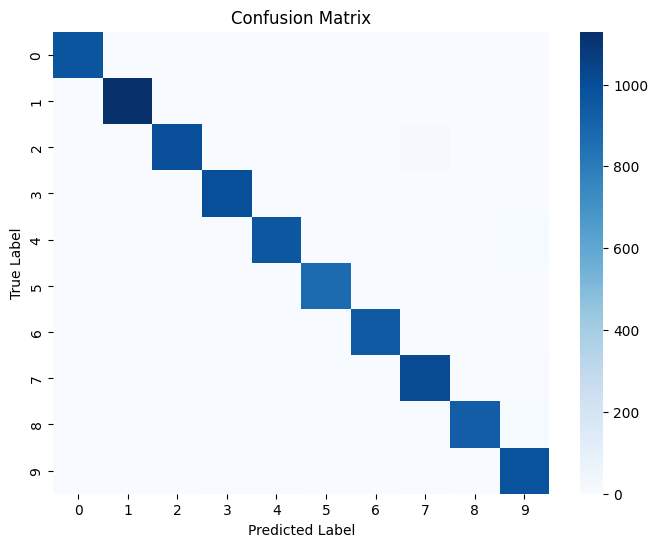


Classification Report:
              precision    recall  f1-score   support

           0     0.9888    0.9898    0.9893       980
           1     0.9904    0.9947    0.9925      1135
           2     0.9891    0.9671    0.9780      1032
           3     0.9774    0.9861    0.9818      1010
           4     0.9766    0.9766    0.9766       982
           5     0.9820    0.9776    0.9798       892
           6     0.9703    0.9885    0.9793       958
           7     0.9665    0.9835    0.9749      1028
           8     0.9842    0.9589    0.9714       974
           9     0.9733    0.9742    0.9737      1009

    accuracy                         0.9799     10000
   macro avg     0.9799    0.9797    0.9797     10000
weighted avg     0.9800    0.9799    0.9799     10000



In [40]:
# -----------------------------
# 3) Training and evaluation
# -----------------------------
def self_test(epochs=10, batch_size=128):
    (X_train, y_train), (X_test, y_test) = load_and_preprocess_mnist()

    # Split validation from training data
    X_val = X_train[-10000:]
    y_val = y_train[-10000:]
    X_train = X_train[:-10000]
    y_train = y_train[:-10000]

    model = build_deep_mlp(input_dim=X_train.shape[1], n_classes=10)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"\nTest Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

    # Confusion matrix
    y_pred = np.argmax(model.predict(X_test), axis=1)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=False, cmap="Blues", fmt="d")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    return {
        "history": history.history,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "confusion_matrix": cm
    }

results = self_test(epochs=10, batch_size=128)

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, we built a complete end-to-end deep learning pipeline using the MNIST dataset. First, we loaded the data, normalized the pixel values, and reshaped the images so they could be used as input to a neural network. Then we built a deeper MLP model with multiple hidden layers and dropout to reduce overfitting. After that, we trained the model using the Adam optimizer and tracked how accuracy improved over each epoch. We then evaluated the model on the test set and used a confusion matrix and classification report to understand where the model performed well and where it made mistakes. Overall, I learned how all the steps, data preprocessing, model design, training, and evaluation, work together to build a strong and reliable machine learning system.


#### **Exercise 12: Monitoring Training with Callbacks (Early Stopping & LR Scheduling)**

In this exercise, you’ll learn how to use **callbacks** in Keras to improve training efficiency and prevent overfitting.  
You will apply **EarlyStopping** to stop training when validation performance stops improving and use **ReduceLROnPlateau** to lower the learning rate when progress stalls.

We’ll reuse the MNIST deep MLP from Exercise 11.

You will:
- Add `EarlyStopping` to stop training early and restore the best weights.
- Add `ReduceLROnPlateau` to reduce learning rate when validation loss plateaus.
- Track how many epochs were actually used.
- Plot learning curves for loss and accuracy to visualize the effect of callbacks.
- Compare results to a baseline run without callbacks.

---


In [41]:
# Exercise 12 — Monitoring Training with Callbacks (Early Stopping & LR Scheduling)

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# -----------------------------
# 1) Load and preprocess MNIST (reuse from Exercise 11)
# -----------------------------
def load_and_preprocess_mnist():
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
    X_train = X_train.astype("float32") / 255.0
    X_test = X_test.astype("float32") / 255.0
    X_train = X_train.reshape((-1, 28*28))
    X_test = X_test.reshape((-1, 28*28))
    return (X_train, y_train), (X_test, y_test)

In [42]:
# -----------------------------
# 2) Build model (reuse from Exercise 11)
# -----------------------------
def build_deep_mlp(input_dim=784, n_classes=10):
    return tf.keras.Sequential([
        tf.keras.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(n_classes)  # logits
    ])


Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8727 - loss: 0.4179 - val_accuracy: 0.9569 - val_loss: 0.1471 - learning_rate: 0.0010
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9468 - loss: 0.1807 - val_accuracy: 0.9668 - val_loss: 0.1068 - learning_rate: 0.0010
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9600 - loss: 0.1348 - val_accuracy: 0.9708 - val_loss: 0.0935 - learning_rate: 0.0010
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9662 - loss: 0.1092 - val_accuracy: 0.9748 - val_loss: 0.0832 - learning_rate: 0.0010
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9722 - loss: 0.0920 - val_accuracy: 0.9766 - val_loss: 0.0795 - learning_rate: 0.0010
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9749 - loss: 0.0797 - val_accuracy: 0.9770 - val_loss: 0.0786 - learning_rate: 0.0010
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9775 - loss: 0.0720 

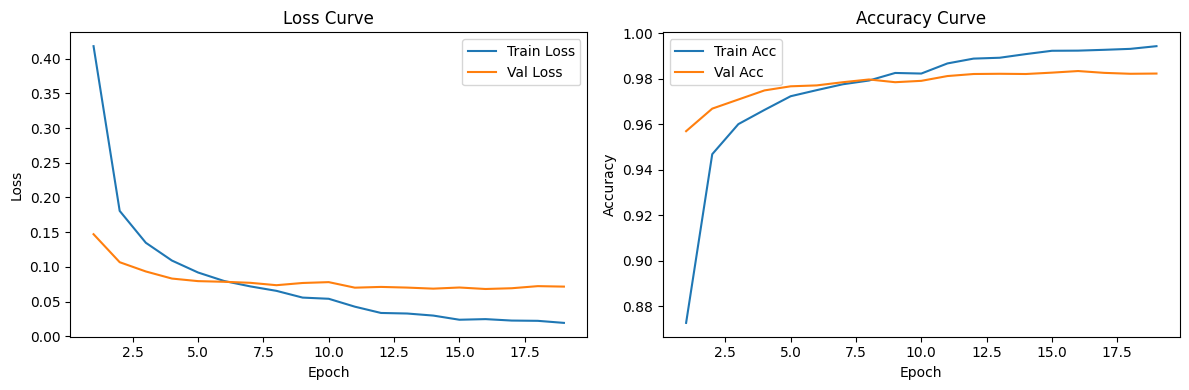

In [43]:
# -----------------------------
# 3) Self-test runner
# -----------------------------
def self_test(epochs=30, batch_size=128):
    (X_train, y_train), (X_test, y_test) = load_and_preprocess_mnist()

    # Validation split
    X_val = X_train[-10000:]
    y_val = y_train[-10000:]
    X_train = X_train[:-10000]
    y_train = y_train[:-10000]

    model = build_deep_mlp(input_dim=X_train.shape[1], n_classes=10)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"]
    )

    # Define callbacks
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"\nStopped after {len(history.history['loss'])} epochs")
    print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

    # Plot learning curves
    epochs_run = range(1, len(history.history['loss']) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(epochs_run, history.history['loss'], label='Train Loss')
    ax[0].plot(epochs_run, history.history['val_loss'], label='Val Loss')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
    ax[0].set_title('Loss Curve')

    ax[1].plot(epochs_run, history.history['accuracy'], label='Train Acc')
    ax[1].plot(epochs_run, history.history['val_accuracy'], label='Val Acc')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Accuracy')
    ax[1].legend()
    ax[1].set_title('Accuracy Curve')

    plt.tight_layout()
    plt.show()

    return {
        "history": history.history,
        "test_loss": test_loss,
        "test_acc": test_acc
    }

results = self_test(epochs=30, batch_size=128)


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, we started by loading and preparing the MNIST dataset and splitting it into training and validation sets. Then we built a deeper neural network with dropout layers to help reduce overfitting. After that, we trained the model using Adam while adding two important callbacks: EarlyStopping and ReduceLROnPlateau. These helped the model stop automatically when it stopped improving and also reduced the learning rate when progress slowed down. We then plotted the training and validation loss and accuracy to clearly see how the model learned over time. From this exercise, I learned that callbacks make training more efficient and stable, and they help prevent wasting time while also improving final performance.


#### **Revised: September 1, 2025**